In [ ]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/fully_cleaned.csv")

In [ ]:
df.head(1)

,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud,Salary (USD),Posting Month,posting_Year,Hiring Urgency,Job Openings
0,Data Analyst,Start-up,Finance,Unknown,Hybrid,Junior,4.0,Bachelor's,1,1,0,0,0,61640.0,10,2024,Low,0


In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   JobTitle             10025 non-null  object 
 1   Company Size         10025 non-null  object 
 2   company_Industry     10025 non-null  object 
 3   Country              10025 non-null  object 
 4   Remote Type          10025 non-null  object 
 5   Exp. Level           10025 non-null  object 
 6   Years_Experience     10025 non-null  float64
 7   Education  Level     10025 non-null  object 
 8   Skills - Python      10025 non-null  int64  
 9   Skills - SQL         10025 non-null  int64  
 10  Skills - ML          10025 non-null  int64  
 11  Skills-DeepLearning  10025 non-null  int64  
 12  skills_Cloud         10025 non-null  int64  
 13  Salary (USD)         10025 non-null  float64
 14  Posting Month        10025 non-null  int64  
 15  posting_Year         10025 non-null 

In [ ]:
skill_cols = [
    'Skills - Python',
    'Skills - SQL',
    'Skills - ML',
    'Skills-DeepLearning',
    'skills_Cloud'
]

In [ ]:
df["Total_Skills"] = df[skill_cols].sum(axis=1)

In [ ]:
df["advanced_skill_score"] = (
    df['Skills - Python'] * 2 +
    df['Skills - SQL'] * 1 +
    df['Skills - ML'] * 3 +
    df['Skills-DeepLearning'] * 4 +
    df['skills_Cloud'] * 3
)

In [ ]:
df["ai_specialist"] = ((df['Skills - ML'] == 1) & (df['Skills-DeepLearning'] == 1)).astype(int)

In [ ]:
df["data_professional"] = ((df['Skills - Python'] == 1) & (df['Skills - SQL'] == 1)).astype(int)

In [ ]:
df["exp_per_skill"] = df['Years_Experience'] / df['Total_Skills']

In [ ]:
df["experience_intensity"] = (
    df['Years_Experience'] *
    df["advanced_skill_score"]
)

In [ ]:
df["salary_per_skill"] = df['Salary (USD)'] / df["Total_Skills"]

In [ ]:
df["high_salary_job"] = (
    df['Salary (USD)'] > df['Salary (USD)'].quantile(0.75)
)

In [ ]:
df["salary_growth_potential"] = df["advanced_skill_score"] * df['Years_Experience']

In [ ]:
df["skill_demand_score"] = df.groupby(skill_cols)['Job Openings'].transform('mean')

In [ ]:
df["industry_hiring_density"] = df.groupby("company_Industry")['Job Openings'].transform('sum')

In [ ]:
df['country_demand_score'] = df.groupby("Country")['Job Openings'].transform('mean')

In [ ]:
df["is_remote"] = (df['Remote Type'] == 'Remote').astype(int)

In [ ]:
df["is_hybrid"] = (df['Remote Type'] == 'Hybrid').astype(int)

In [ ]:
df['remote_premium_salary'] = df['Salary (USD)'] / (df.groupby("Remote Type")['Salary (USD)'].transform("mean"))

In [ ]:
a = df['Salary (USD)'].quantile(0.25)
b = df['Salary (USD)'].quantile(0.50)
c = df['Salary (USD)'].quantile(0.75)

In [ ]:
def salary_distribution(salary):
  if salary <= a :
    return "Low"
  elif salary <= b :
    return "Moderate"
  else :
    return "High"

In [ ]:
df['Salary_Distribution'] = df['Salary (USD)'].apply(salary_distribution)

In [ ]:
quarter = {
    1:'Q1', 2:'Q1', 3:'Q1',
    4:'Q2', 5:'Q2', 6:'Q2',
    7:'Q3', 8:'Q3', 9:'Q3',
    10:'Q4', 11:'Q4', 12:'Q4'
}

df['hiring_quarter'] = df['Posting Month'].map(quarter)

In [ ]:
df['peak_hiring_season'] = df['Posting Month'].isin([1,2,3,9,10]).astype(int)

In [ ]:
df["ml_cloud_combination"] = (df['Skills - ML'] * df['skills_Cloud'])

In [ ]:
df['python_sql_combination'] = (df['Skills - Python'] * df['Skills - SQL'])

In [ ]:
df['salary_percentile'] = (df['Salary (USD)'].rank(pct=True))

In [ ]:
df['salary_zscore'] = ((df['Salary (USD)'] - df['Salary (USD)'].mean()) / df['Salary (USD)'].std())

In [ ]:
industry_salary = df.groupby("company_Industry")['Salary (USD)'].mean()

df['industry_salary'] = (df['company_Industry'].map(industry_salary))

In [ ]:
country_salary = df.groupby("Country")['Salary (USD)'].mean()

df['country_salary'] = (df['Country'].map(country_salary))

In [ ]:
df['competition_ratio'] = (df['Job Openings'] / (df['Total_Skills'] + 1))

In [ ]:
df['experience_squared'] = (df['Years_Experience'] ** 2)

In [ ]:
df['skill_intersection_power'] = (df['Total_Skills'] ** df['Years_Experience'])

In [ ]:
df['industry_salary_rank'] = (df.groupby("company_Industry")['Salary (USD)'].rank(pct=True))

In [ ]:
df['hiring_momentum'] = (df.groupby("Posting Month")['Job Openings'].transform('mean'))

In [ ]:
df['market_expansion_score'] = (df.groupby("posting_Year")['Job Openings'].transform('sum'))

In [ ]:
job_freq = df['JobTitle'].value_counts()

df['job_title_popularity'] = df['JobTitle'].map(job_freq)

In [ ]:
industry_freq = df['company_Industry'].value_counts()

df['industry_frequency'] = df['company_Industry'].map(industry_freq)

In [ ]:
expected_salary = df.groupby('JobTitle')['Salary (USD)'].transform('mean')

df['salary_gap'] = df['Salary (USD)'] - expected_salary

In [ ]:
df['premium_candidate'] = (df['Salary (USD)'] >= (df['Salary (USD)'].quantile(0.9))).astype(int)

In [ ]:
df["ai_seniority_score"] = (
    df['Skills - ML'] *
    df['Skills-DeepLearning'] *
    df['Years_Experience']
)

In [ ]:
df["cloud_ai_engineer_score"] = (
    df['Skills - ML'] +
    df['Skills-DeepLearning'] +
    df['skills_Cloud']
)

In [ ]:
df.head(1)

,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,...,skill_intersection_power,industry_salary_rank,hiring_momentum,market_expansion_score,job_title_popularity,industry_frequency,salary_gap,premium_candidate,ai_seniority_score,cloud_ai_engineer_score
0,Data Analyst,Start-up,Finance,Unknown,Hybrid,Junior,4.0,Bachelor's,1,1,...,16.0,0.025705,0.0,0,1626,1595,-41840.824723,0,0.0,0


In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings', 'Total_Skills',
       'advanced_skill_score', 'ai_specialist', 'data_professional',
       'exp_per_skill', 'experience_intensity', 'salary_per_skill',
       'high_salary_job', 'salary_growth_potential', 'skill_demand_score',
       'industry_hiring_density', 'country_demand_score', 'is_remote',
       'is_hybrid', 'remote_premium_salary', 'Salary_Distribution',
       'hiring_quarter', 'peak_hiring_season', 'ml_cloud_combination',
       'python_sql_combination', 'salary_percentile', 'salary_zscore',
       'industry_salary', 'country_salary', 'competition_ratio',
       'experience_squared', 'skill_intersection_power',
       'industry_salary_rank', 'hi

In [ ]:
df.to_csv('feature_construction.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   JobTitle                  10025 non-null  object 
 1   Company Size              10025 non-null  object 
 2   company_Industry          10025 non-null  object 
 3   Country                   10025 non-null  object 
 4   Remote Type               10025 non-null  object 
 5   Exp. Level                10025 non-null  object 
 6   Years_Experience          10025 non-null  float64
 7   Education  Level          10025 non-null  object 
 8   Skills - Python           10025 non-null  int64  
 9   Skills - SQL              10025 non-null  int64  
 10  Skills - ML               10025 non-null  int64  
 11  Skills-DeepLearning       10025 non-null  int64  
 12  skills_Cloud              10025 non-null  int64  
 13  Salary (USD)              10025 non-null  float64
 14  Postin

**EDA**

In [ ]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# what is the relationship between JobTitle and job_title_popularity
pop = df.groupby('JobTitle')['job_title_popularity'].mean()
pop.sort_values(ascending=False)

,job_title_popularity
JobTitle,
Business Analyst,1714.0
Machine Learning Engineer,1682.0
AI Engineer,1679.0
Data Scientist,1661.0
Data Analyst,1626.0
Data Engineer,1623.0
Unknown,40.0


In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings', 'Total_Skills',
       'advanced_skill_score', 'ai_specialist', 'data_professional',
       'exp_per_skill', 'experience_intensity', 'salary_per_skill',
       'high_salary_job', 'salary_growth_potential', 'skill_demand_score',
       'industry_hiring_density', 'country_demand_score', 'is_remote',
       'is_hybrid', 'remote_premium_salary', 'Salary_Distribution',
       'hiring_quarter', 'peak_hiring_season', 'ml_cloud_combination',
       'python_sql_combination', 'salary_percentile', 'salary_zscore',
       'industry_salary', 'country_salary', 'competition_ratio',
       'experience_squared', 'skill_intersection_power',
       'industry_salary_rank', 'hi

  ml_cloud_combination   Salary (USD)
0        No ML + Cloud  112736.295243
1           ML + Cloud  123645.885903


/tmp/ipykernel_6494/3385811074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ml_cloud_combination', y='Salary (USD)', data=avg_salary_ml_cloud, palette='viridis')


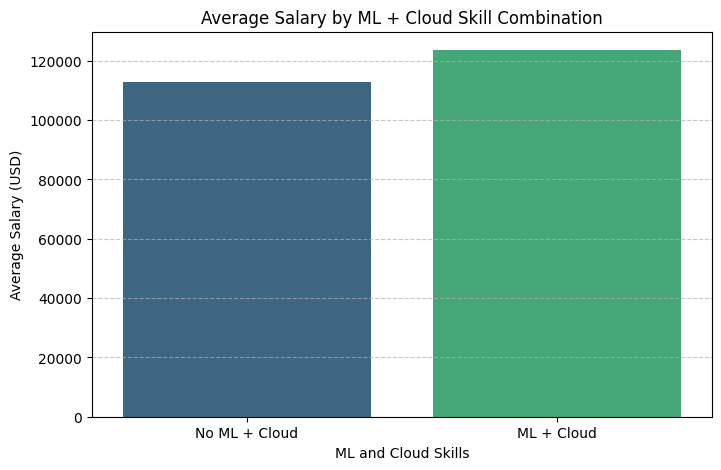

In [ ]:
# Is there a significant salary premium for cloud + ML combined skills?
avg_salary_ml_cloud = df.groupby('ml_cloud_combination')['Salary (USD)'].mean().reset_index()
avg_salary_ml_cloud['ml_cloud_combination'] = avg_salary_ml_cloud['ml_cloud_combination'].map({0: 'No ML + Cloud', 1: 'ML + Cloud'})

print(avg_salary_ml_cloud)

fig = plt.figure(figsize=(8, 5))

sns.barplot(
    x = 'ml_cloud_combination',
    y = 'Salary (USD)',
    data = avg_salary_ml_cloud,
    palette = 'viridis'
)

plt.title('Average Salary by ML + Cloud Skill Combination')
plt.xlabel('ML and Cloud Skills')
plt.ylabel('Average Salary (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude columns that are direct measures or close proxies of salary itself
excluded_salary_related = [
    'Salary (USD)', 'salary_percentile', 'salary_zscore', 'salary_gap',
    'remote_premium_salary', 'industry_salary_rank', 'high_salary_job', 'premium_candidate'
]

# Filter out excluded columns
features_for_correlation = [col for col in numerical_cols if col not in excluded_salary_related]

# Calculate correlations
correlations = df[features_for_correlation].corrwith(df['high_salary_job']).sort_values(ascending=False)

print("Top 10 Positive Correlations with 'high_salary_job':")
print(correlations.head(10))

print("\nTop 10 Negative Correlations with 'high_salary_job':")
print(correlations.tail(10))

Top 10 Positive Correlations with 'high_salary_job':
cloud_ai_engineer_score    0.190481
advanced_skill_score       0.176376
ai_specialist              0.170311
Total_Skills               0.138983
ai_seniority_score         0.137736
Skills-DeepLearning        0.137725
ml_cloud_combination       0.132371
Skills - ML                0.112194
experience_intensity       0.098523
salary_growth_potential    0.098523
dtype: float64

Top 10 Negative Correlations with 'high_salary_job':
industry_frequency        -0.01827
Job Openings                   NaN
exp_per_skill                  NaN
salary_per_skill               NaN
skill_demand_score             NaN
industry_hiring_density        NaN
country_demand_score           NaN
competition_ratio              NaN
hiring_momentum                NaN
market_expansion_score         NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


/tmp/ipykernel_6494/4174466251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.head(10).values, y=correlations.head(10).index, palette='viridis')


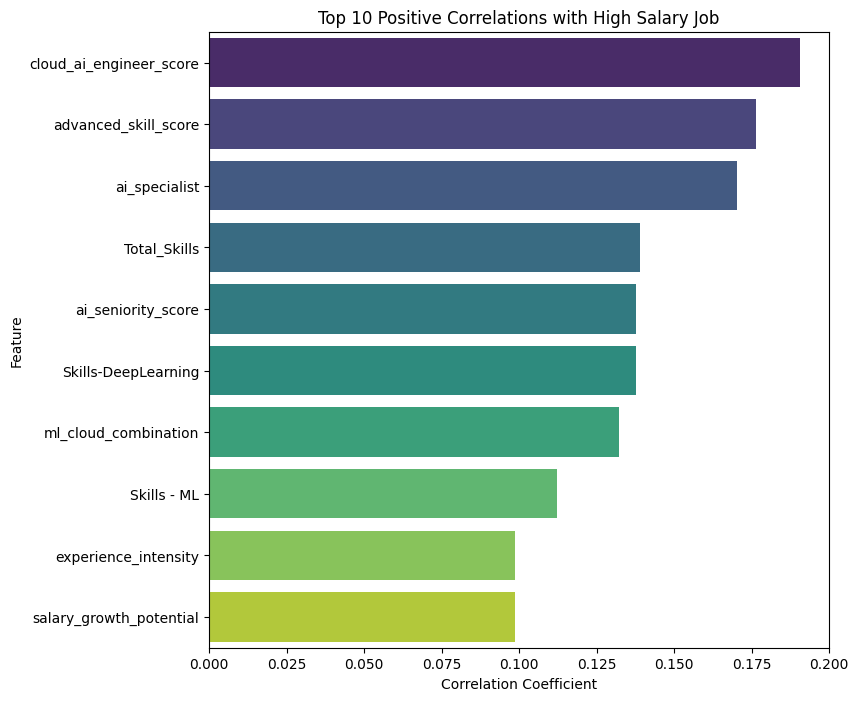

In [ ]:
# Visualize top positive and negative correlations
fig = plt.figure(figsize=(8, 8))
sns.barplot(x=correlations.head(10).values, y=correlations.head(10).index, palette='viridis')
plt.title('Top 10 Positive Correlations with High Salary Job')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

/tmp/ipykernel_6494/1147456645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.tail(10).values, y=correlations.tail(10).index, palette='plasma')


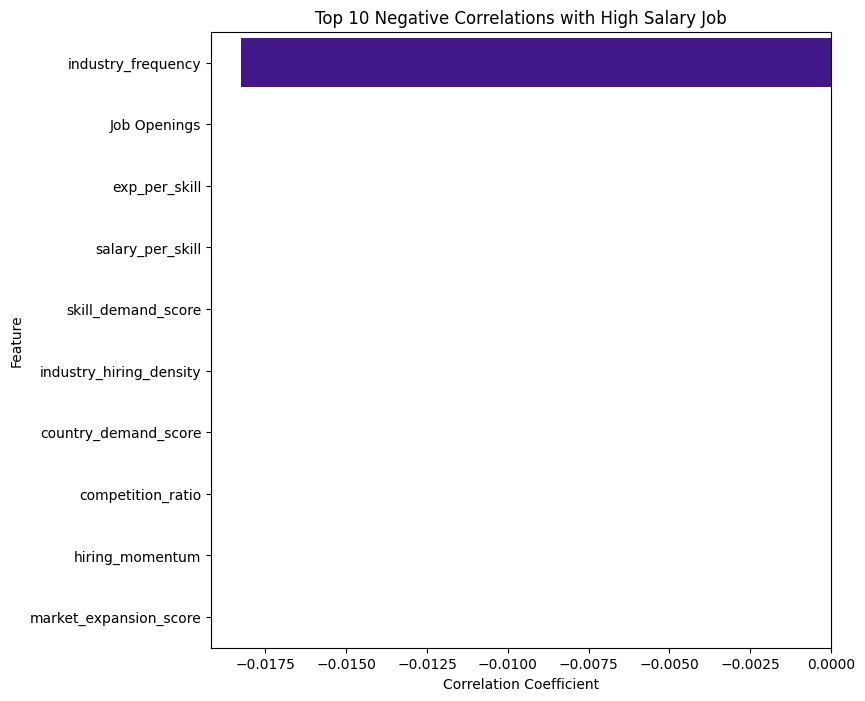

In [ ]:

fig = plt.figure(figsize=(8, 8))
sns.barplot(x=correlations.tail(10).values, y=correlations.tail(10).index, palette='plasma')
plt.title('Top 10 Negative Correlations with High Salary Job')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()